# 02 Numerical Preliminaries

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/02-Numerical-Methods/02_Numerical_Preliminaries.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=02-Numerical-Methods/02_Numerical_Preliminaries.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)
## The Lens: The Illusion of Continuity
**What problem are we solving?**  
Economic theory deals with continuous variables: prices, quantities, probabilities. We write models using real numbers ($\mathbb{R}$). But computers are discrete machines. They cannot represent the continuum. They approximate real numbers using **floating-point arithmetic**, which introduces small but cumulative errors.

**Why this method?**  
Understanding the limitations of the machine is the first step in computational economics.
*   **Machine Epsilon:** The gap between 1.0 and the next representable float — a measure of relative precision (absolute spacing grows with magnitude).
*   **Round-off Error:** The error introduced by finite precision.
*   **Truncation Error:** The error introduced by approximating an infinite process (like a limit) with a finite one.

This notebook is about "knowing your tools." Before we solve complex models, we must understand how the computer counts.

**Economic question.** In *02 Numerical Preliminaries*, what must remain economically invariant when the computational representation changes? In economic computation, an algorithm is part of the model: convergence tolerances, conditioning, discretization, and stopping rules can alter the apparent equilibrium. The central question is therefore not merely whether a routine returns a number, but whether that number is stable under tighter tolerances, alternative initial conditions, and an independent method. Treat every numerical result as an approximation with a measurable error budget.

## Learning Objectives

By the end of this notebook, you will be able to:
1.  **Explain** how computers represent numbers using IEEE 754 standard.
2.  **Quantify** numerical errors (Absolute, Relative, Round-off, Truncation).
3.  **Diagnose** stability and conditioning issues in algorithms.
4.  **Implement** arbitrary-precision arithmetic when necessary.
5.  **Analyze** the algorithmic complexity (Big-O) of your code.

## Prerequisites

*   **01-Foundations/12_NumPy.ipynb**: Basic NumPy usage.
* **Learning-path prerequisite:** [`01_Linear_Algebra.ipynb`](01_Linear_Algebra.ipynb)

> **Learning path:** Building on [`01_Linear_Algebra.ipynb`](01_Linear_Algebra.ipynb); next continue with [`03_Numerical_Differentiation.ipynb`](03_Numerical_Differentiation.ipynb).


In [1]:
# === Environment Setup ===
import struct
from decimal import Decimal, getcontext

import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12, 'figure.dpi': 120})
%config InlineBackend.figure_format = 'retina'
np.set_printoptions(suppress=True, linewidth=120, precision=8)
getcontext().prec = 50 # Set precision for Decimal objects


# Table of Contents
* [The Lens: The Illusion of Continuity](#the-lens-the-illusion-of-continuity)
* [Learning Objectives](#learning-objectives)
* [Prerequisites](#prerequisites)
* [1. How Computers Represent Numbers](#1-how-computers-represent-numbers)
  * [1.1 IEEE 754 Floating-Point Representation](#11-ieee-754-floating-point-representation)
  * [1.2 Machine Epsilon](#12-machine-epsilon)
  * [1.3 Special Values: Infinity and NaN](#13-special-values-infinity-and-nan)
* [2. A Taxonomy of Numerical Error](#2-a-taxonomy-of-numerical-error)
  * [Absolute vs. Relative Error](#absolute-vs-relative-error)
  * [Forward vs. Backward Error](#forward-vs-backward-error)
* [3. Diagnosing Problems: Conditioning and Stability](#3-diagnosing-problems-conditioning-and-stability)
  * [3.1 Conditioning (The Problem)](#31-conditioning-the-problem)
  * [3.2 Stability (The Algorithm)](#32-stability-the-algorithm)
  * [Kahan Summation Algorithm](#kahan-summation-algorithm)
* [4. Arbitrary-Precision Arithmetic](#4-arbitrary-precision-arithmetic)
* [5. Rates of Convergence](#5-rates-of-convergence)
* [6. Algorithmic Complexity](#6-algorithmic-complexity)
  * [Amortized Analysis](#amortized-analysis)
* [Summary](#summary)
  * [Appendix: Visualizing the Floating Point Gap](#appendix-visualizing-the-floating-point-gap)
* [Exercises](#exercises)
  * [1. Conceptual: Harmonic Series Paradox](#1-conceptual-harmonic-series-paradox)
  * [2. Applied: Robust Quadratic Solver](#2-applied-robust-quadratic-solver)
  * [3. Challenge: Financial Precision](#3-challenge-financial-precision)


## 1. How Computers Represent Numbers

### 1.1 IEEE 754 Floating-Point Representation

A standard 64-bit float (`float64` in NumPy) consists of:
1.  **Sign Bit (1 bit):** Positive or negative.
2.  **Exponent (11 bits):** Magnitude range.
3.  **Mantissa (52 bits):** Precision (significant digits).

For a normal finite value with stored exponent $1 \le e \le 2046$ and stored 52-bit fraction integer $m$,

$$x=(-1)^s(1+m/2^{52})2^{e-1023}.$$

The code below prints $m$ as an integer, not the fraction $m/2^{52}$. Exponent $e=0$ encodes zeros and subnormals (no implicit leading 1); $e=2047$ encodes infinities and NaNs.

**Consequence:** Numbers like `0.1` cannot be represented exactly in binary, leading to `0.1 + 0.2 != 0.3`.


In [2]:
def float_to_bits(f):
    """Unpacks a 64-bit float into its sign, exponent, and mantissa bits."""
    packed = struct.pack('!d', f)
    integers = struct.unpack('!Q', packed)[0]
    # Extract bits
    sign = (integers >> 63) & 1
    exponent = (integers >> 52) & 0x7FF
    mantissa = integers & 0xFFFFFFFFFFFFF
    return sign, exponent, mantissa

s, e, m = float_to_bits(19.94)
print("Float: 19.94")
print(f"Sign: {s}")
print(f"Exponent: {e} (Stored)")
print(f"Mantissa: {m}")


Float: 19.94
Sign: 0
Exponent: 1027 (Stored)
Mantissa: 1109011408239985


### 1.2 Machine Epsilon

**Machine Epsilon** ($\epsilon_{mach}$) is the distance from 1.0 to the next largest representable float. For 64-bit floats, $\epsilon_{mach} \approx 2.22 \times 10^{-16}$.

**Crucially**, the spacing between floats is **not uniform**. It grows with magnitude. The gap between 1.0 and 2.0 is small; the gap between $10^{16}$ and the next number is large (> 1.0).

### 1.3 Special Values: Infinity and NaN

The IEEE 754 standard reserves specific bit patterns for non-real results:
*   **Infinity (`inf`):** Can result from NumPy overflow (`np.exp(1000.0)`) or nonzero division by zero (`np.divide(1.0, 0.0)`), normally with a runtime warning. Python scalar `1.0 / 0.0` instead raises `ZeroDivisionError`.
*   **Not a Number (`nan`):** Results from invalid NumPy operations such as `np.divide(0.0, 0.0)` or `np.inf - np.inf`. Python scalar `0.0 / 0.0` raises `ZeroDivisionError`. 
    *   *Warning:* `nan != nan`. Always use `np.isnan()` to check.


In [3]:
eps = np.finfo(float).eps
print(f"Machine Epsilon: {eps:.2e}")

gap_at_1 = np.nextafter(1.0, 2.0) - 1.0
gap_at_large = np.nextafter(1e16, 2e16) - 1e16

print(f"Gap at 1.0:      {gap_at_1:.2e}")
print(f"Gap at 1e16:     {gap_at_large:.2f}")
print("Notice: At 1e16, the computer cannot represent odd integers!")


Machine Epsilon: 2.22e-16
Gap at 1.0:      2.22e-16
Gap at 1e16:     2.00
Notice: At 1e16, the computer cannot represent odd integers!


## 2. A Taxonomy of Numerical Error

1.  **Rounding Error:** Caused by finite precision (e.g., storing $\pi$ as a float).
2.  **Truncation Error:** Caused by approximating an infinite process (e.g., Taylor series, iterative limit) with a finite one.

### Absolute vs. Relative Error

*   **Absolute:** $E_{abs} = |x_{true} - x_{approx}|$
*   **Relative:** $E_{rel} = \frac{|x_{true} - x_{approx}|}{|x_{true}|}$

### Forward vs. Backward Error
This distinction is crucial for stability analysis:
*   **Forward Error:** The difference between the computed answer and the true answer ($|y_{computed} - y_{true}|$). This is what we usually care about.
*   **Backward Error:** The size of the perturbation to the *input* that would make the computed answer the *exact* answer for that perturbed input. If an algorithm has small backward error, it is "Backward Stable". It gives the right answer to a slightly wrong problem.

**Error Propagation Formula:**
If $x_{approx} = x (1 + \epsilon_x)$ and $y_{approx} = y (1 + \epsilon_y)$:
*   **Multiplication:** $x_{approx} y_{approx} \approx xy(1 + \epsilon_x + \epsilon_y)$. Relative errors add.
*   **Addition:** $x_{approx} + y_{approx} = (x+y) + x\epsilon_x + y\epsilon_y$. Relative error is $\frac{x\epsilon_x + y\epsilon_y}{x+y}$. If $x \approx -y$, the denominator is small, and error explodes (**Cancellation**).

![Taylor Error](../images/02-Numerical-Methods/taylor_error.png)
*Figure: Visualizing the trade-off between truncation error and round-off error. As the step size gets too small, round-off error dominates.*

**Best Practice:** Always use relative error (or `np.isclose` which handles both) unless the value is near zero.


## 3. Diagnosing Problems: Conditioning and Stability

### 3.1 Conditioning (The Problem)
A problem is **ill-conditioned** if small changes in inputs cause huge changes in outputs. Example: Solving $Ax=b$ with a Hilbert matrix.

### 3.2 Stability (The Algorithm)
An algorithm is **unstable** if it amplifies rounding errors. Example: **Catastrophic Cancellation** when subtracting two nearly equal numbers.


In [4]:
# Demonstrating Catastrophic Cancellation in Variance Calculation
rng = np.random.default_rng(42)
# Large mean, small variance
x = rng.normal(1e9, 1.0, size=10000)

# Naive formula: E[x^2] - (E[x])^2
var_naive = np.mean(x**2) - np.mean(x)**2

# Stable formula (NumPy's implementation)
var_stable = np.var(x)

print("True Variance:   1.0 (approx)")
print(f"Stable Var:      {var_stable:.4f}")
print(f"Naive Var:       {var_naive:.4f} (Often completely wrong or negative!)")


True Variance:   1.0 (approx)
Stable Var:      1.0126
Naive Var:       0.0000 (Often completely wrong or negative!)


In [5]:
# Demonstrating Catastrophic Cancellation in Quadratic Formula
# Equation: ax^2 + bx + c = 0. Roots: (-b +/- sqrt(b^2 - 4ac)) / 2a
# If b^2 >> |4ac|, then sqrt(b^2 - 4ac) ~ b, so (-b + sqrt(...))
# subtracts two nearly equal numbers and most digits are lost.
a = 1.0
b = 1.0e8
c = 1.0

# Naive Standard Formula for the smaller root (requires subtraction)
root_naive = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)

# Rationalized Formula (avoids subtraction)
root_stable = -2*c / (b + np.sqrt(b**2 - 4*a*c))

print(f"Naive Root:  {root_naive}")
print(f"Stable Root: {root_stable}")
print(f"Relative error of the naive root: {abs(root_naive - root_stable) / abs(root_stable):.1%}")

Naive Root:  -7.450580596923828e-09
Stable Root: -1e-08
Relative error of the naive root: 25.5%


In [6]:
# Example: Loss of Significance in Finance
# Subtracting two large, nearly identical numbers (e.g., bond prices) results in loss of precision.
price_A = 100000.000000001
price_B = 100000.000000000

# Each input near 1e5 carries ~16 significant digits but has an
# absolute rounding uncertainty of about half an ulp (~7e-12).
# Their tiny difference inherits that same absolute uncertainty,
# so only about two of its digits are trustworthy.
diff = price_A - price_B
print(f"Difference: {diff}")
print("Most digits were lost in the subtraction: the inputs are each uncertain by ~1e-11, so this ~1e-9 difference keeps only ~2 reliable significant digits.")

Difference: 1.0040821507573128e-09
Most digits were lost in the subtraction: the inputs are each uncertain by ~1e-11, so this ~1e-9 difference keeps only ~2 reliable significant digits.


### Kahan Summation Algorithm
When summing many numbers (like computing the mean of a large dataset), rounding errors accumulate: naive left-to-right addition has a worst-case error that grows linearly with the number of terms $n$. Kahan summation keeps a separate *compensation* variable that captures the low-order bits lost at each addition and feeds them back into the next one:

```python
y = x - c           # adjust the input by the prior compensation
t = s + y           # rounded sum
c = (t - s) - y     # recovers exactly the bits that rounding just discarded
s = t
```

This shrinks the accumulated error from $O(n\,\epsilon_{mach})$ to roughly $O(\epsilon_{mach})$, independent of $n$. In practice, prefer battle-tested implementations: `math.fsum` returns the correctly rounded sum, and NumPy's `np.sum` tames error growth via pairwise (blocked) summation.

## 4. Arbitrary-Precision Arithmetic

For finance (where every penny counts) or high-precision math, standard floats are insufficient. Python's `decimal` module represents finite decimal inputs exactly when constructed from strings; operations still round to the active context precision. For example, `Decimal('1') / Decimal('3')` is not exact. Set precision and rounding rules explicitly for the calculation.

In [7]:
val_float = 0.1 + 0.1 + 0.1 - 0.3
print(f"Float Math:   {val_float:.20f} (Not zero!)")

val_decimal = Decimal('0.1') + Decimal('0.1') + Decimal('0.1') - Decimal('0.3')
print(f"Decimal Math: {val_decimal} (Exact)")


Float Math:   0.00000000000000005551 (Not zero!)
Decimal Math: 0.0 (Exact)


## 5. Rates of Convergence

When iterating (e.g., to find a root $x^*$), how fast does the error $\epsilon_k = |x_k - x^*|$ shrink?

1.  **Linear Convergence:** $\epsilon_{k+1} \le C \epsilon_k$ with $C < 1$. The number of correct digits increases by a constant amount each step. (e.g., Bisection).
2.  **Quadratic Convergence:** $\epsilon_{k+1} \le C \epsilon_k^2$. The number of correct digits *doubles* each step. (e.g., Newton's Method).

Quadratic is much faster. If $\epsilon_k = 10^{-2}$, then $\epsilon_{k+1} \approx 10^{-4}$, $\epsilon_{k+2} \approx 10^{-8}$.


## 6. Algorithmic Complexity

**Big-O Notation** describes how runtime scales with input size $N$.

*   $O(1)$: Constant (Dictionary lookup).
*   $O(N)$: Linear (Looping through a list).
*   $O(N \log N)$: Log-Linear (Sorting, FFT). Crucial for efficient heterogeneous agent models.
*   $O(N^2)$: Quadratic (Nested loops, matrix-vector multiplication).
*   $O(N^3)$: Cubic (Matrix multiplication/inversion). Common in econometrics (OLS).

![Big O Complexity](../images/02-Numerical-Methods/big_o_complexity.png)
*Figure: Growth rates of different complexity classes. Notice how fast exponential time explodes.*

### Amortized Analysis
Some operations are expensive occasionally but cheap on average. 
*   Example: Appending to a Python list. Usually $O(1)$, but occasionally $O(N)$ when the memory buffer fills up and the list must be copied. The *amortized* cost is $O(1)$.


## Summary

**Key Takeaways:**
*   **Floats are approximations:** Use `np.isclose` with problem-appropriate tolerances for approximate numerical results; exact equality is still appropriate when exact identity is intended.
*   **Conditioning Matters:** A stable algorithm cannot fix an ill-conditioned problem.
*   **Avoid Cancellation:** Rewrite formulas (like variance or the quadratic formula) to avoid subtracting nearly equal numbers.
*   **Know the Cost:** Be aware of the Big-O complexity of your operations, especially inside loops.


### Appendix: Visualizing the Floating Point Gap
To really internalize the density of floating point numbers, let's visualize them. Notice how they are dense near zero and become sparse as magnitude increases.


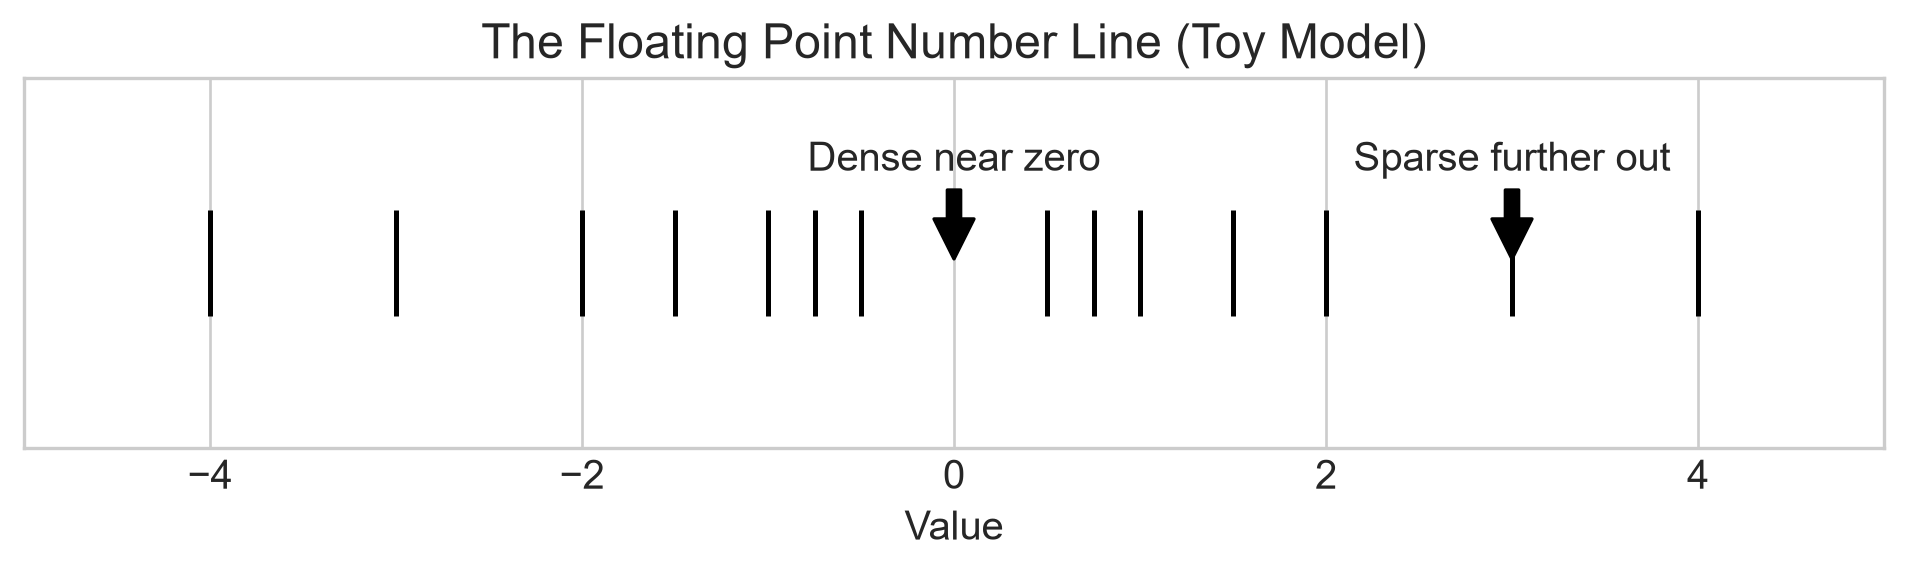

In [8]:
# Visualizing 4-bit Floats (Toy Example)
# Assume 1 bit sign, 2 bits exponent, 1 bit mantissa for visualization

def get_toy_floats():
    values = []
    # Sign: 0 (pos) or 1 (neg)
    for s in [0, 1]:
        sign = (-1)**s
        # Exponent: 0 to 3. Bias = 1.
        for e in range(4):
            exponent = 2**(e - 1)
            # Mantissa: 0 or 1. (1 + m/2)
            for m in range(2):
                mantissa = 1 + m/2
                val = sign * mantissa * exponent
                values.append(val)
    return sorted(list(set(values)))

toy_vals = get_toy_floats()

plt.figure(figsize=(10, 2))
plt.scatter(toy_vals, np.zeros_like(toy_vals), marker='|', s=1000, c='k')
plt.xlim(-5, 5)
plt.ylim(-0.1, 0.1)
plt.yticks([])
plt.title("The Floating Point Number Line (Toy Model)")
plt.xlabel("Value")
plt.annotate('Dense near zero', xy=(0, 0), xytext=(0, 0.05), ha='center', arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Sparse further out', xy=(3, 0), xytext=(3, 0.05), ha='center', arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()


## Exercises

### 1. Conceptual: Harmonic Series Paradox
The harmonic series $\sum \frac{1}{n}$ diverges. Write a script to sum this series using `float32`. Does it diverge or converge? Why?

### 2. Applied: Robust Quadratic Solver
The standard quadratic formula $\frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$ is unstable when $b^2 \gg 4ac$. Implement a function `solve_quadratic(a, b, c)` that uses the alternative form or rationalization to avoid catastrophic cancellation.

### 3. Challenge: Financial Precision
Calculate the value of a $1 investment at 5% interest compounded annually for 100 years. Compare `float` vs `Decimal`. At what year do they diverge by more than 1 cent?

**Failure analysis (Challenge):** Summing mixed-magnitude returns in different orders can change the computed total. Reproduce this with `[1e16, 1.0, -1e16]` and `[1e16, -1e16, 1.0]` using an explicit left-to-right loop (`total = 0.0;` then `total += value` for each element; exact total: 1). Do not use built-in `sum` as the naive baseline: recent Python versions use a more accurate floating-point summation algorithm. Diagnose the non-associativity of floating-point addition, repair with `math.fsum` or pairwise summation, and bound the worst-case error of the naive left-to-right sum.

## References & Further Reading

- Judd, K. L. (1998). *Numerical Methods in Economics*. MIT Press.
- Miranda, M. J. & Fackler, P. L. (2002). *Applied Computational Economics and Finance*. MIT Press.
- Nocedal, J. & Wright, S. J. (2006). *Numerical Optimization* (2nd ed.). Springer.
